# Neural Network Classification with Pytorch

Classification is a problem whether something is one thing or another ( there can be multiple things as the options).

# Make Classification Data and get it ready

In [57]:
from sklearn.datasets import make_circles

# make 1000 samples
n_samples = 1000

# make Circles
X, Y = make_circles(n_samples,
                    noise=0.03,
                    random_state=42)
print(f'len of X : \n{len(X)}\n-------------')
print(f'len of Y : \n{len(Y)}')
print('\n----------------------\n')
print(f'First 5 samples of X : \n{X[:5]}\n------------')
print(f'First 5 samples of Y : \n{Y[:5]}')

len of X : 
1000
-------------
len of Y : 
1000

----------------------

First 5 samples of X : 
[[ 0.75424625  0.23148074]
 [-0.75615888  0.15325888]
 [-0.81539193  0.17328203]
 [-0.39373073  0.69288277]
 [ 0.44220765 -0.89672343]]
------------
First 5 samples of Y : 
[1 1 1 1 0]


In [58]:
# make a DataFreame of Circles Data
import pandas as pd
circles = pd.DataFrame({
    'X1' : X[:, 0],
    'X2' : X[:, 1],
    'label' : Y
})
print(circles)

           X1        X2  label
0    0.754246  0.231481      1
1   -0.756159  0.153259      1
2   -0.815392  0.173282      1
3   -0.393731  0.692883      1
4    0.442208 -0.896723      0
..        ...       ...    ...
995  0.244054  0.944125      0
996 -0.978655 -0.272373      0
997 -0.136900 -0.810012      1
998  0.670362 -0.767502      0
999  0.281057  0.963824      0

[1000 rows x 3 columns]


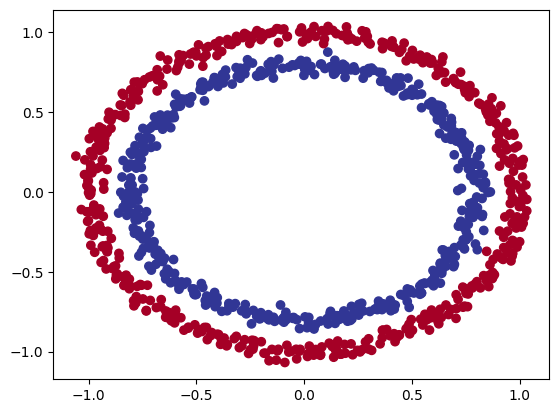

In [59]:
# Visualize
import matplotlib.pyplot as plt
plt.scatter(
    x=X[:, 0],
    y=X[:, 1],
    c=Y,
    cmap=plt.cm.RdYlBu
)
plt.show()

**Note**: the data we're working with is often referred to as the toy dataset, a dataset that is small enough to experiment but still sizeable enough to practice the fundamentals.

### 1.1 check input & output shapes

In [60]:
print(f'--X--- {X.shape} ---Y--- {Y.shape}')

--X--- (1000, 2) ---Y--- (1000,)


In [61]:
# View the First example of Features & Labels
print(f'the First example of Features : {X[0]} and shape: {X[0].shape} \n')
print(f'the First example of Labels : {Y[0]} and shape: {Y[0].shape}')

the First example of Features : [0.75424625 0.23148074] and shape: (2,) 

the First example of Labels : 1 and shape: ()


### 1.2 Turn Data into Tensor and Create train and test split

In [62]:
import torch as t
print(t.__version__)

2.11.0+cu130


In [63]:
print(type(X))
print(type(Y))

<class 'numpy.ndarray'>
<class 'numpy.ndarray'>


In [64]:
# tern data to the Tensor
X = t.from_numpy(X).type(t.float32)
Y = t.from_numpy(Y).type(t.float32)
print(type(X))
print(type(Y))
print('\n-------------\n')
print(X[:5])
print(Y[:5])

<class 'torch.Tensor'>
<class 'torch.Tensor'>

-------------

tensor([[ 0.7542,  0.2315],
        [-0.7562,  0.1533],
        [-0.8154,  0.1733],
        [-0.3937,  0.6929],
        [ 0.4422, -0.8967]])
tensor([1., 1., 1., 1., 0.])


In [65]:
# Split Data into Training & testing Sets
from sklearn.model_selection import train_test_split
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

print(' ----------------X_train ----------------')
print(X_train)
print('\n----------------\n')
print(' ----------------X_test ----------------')
print(X_test)
print('\n----------------\n')
print(' ----------------Y_train ----------------')
print(Y_train)
print('\n----------------\n')
print(' ----------------Y_test ----------------')
print(Y_test)

 ----------------X_train ----------------
tensor([[ 0.6579, -0.4651],
        [ 0.6319, -0.7347],
        [-1.0086, -0.1240],
        ...,
        [ 0.0157, -1.0300],
        [ 1.0110,  0.1680],
        [ 0.5578, -0.5709]])

----------------

 ----------------X_test ----------------
tensor([[-3.7519e-01,  6.8266e-01],
        [ 1.5380e-02,  9.6003e-01],
        [-7.0278e-01, -3.1472e-01],
        [-2.8525e-01,  9.6638e-01],
        [ 4.0242e-01, -7.4375e-01],
        [ 6.3228e-01, -5.7111e-01],
        [ 8.5607e-01,  5.4994e-01],
        [ 1.0034e+00,  1.9028e-01],
        [-7.4892e-01, -2.9511e-01],
        [ 5.3780e-02,  9.7388e-01],
        [-4.7020e-01,  7.8749e-01],
        [-2.1686e-01,  7.2418e-01],
        [ 9.7026e-01,  3.6688e-01],
        [-5.8446e-01, -5.7415e-01],
        [-9.1147e-01, -2.4631e-01],
        [ 7.6892e-01, -7.3249e-02],
        [ 3.8408e-01,  6.8299e-01],
        [-6.8364e-01,  7.1417e-01],
        [-5.7777e-01,  5.3652e-01],
        [-8.3274e-01,  4.6625e-0

### 2. Building a Model

let's build a model to classify our red and blue dot.

To do so, we want to:
1. Setup device agnostic code so our code will run on an accelerator (GPU) if there is one
2. Construct a model (by subclassing 'nn.Module')
3. define a loss function & optimizer
4. Create a training * test Loop

In [66]:
device = 'cuda' if t.cuda.is_available() else 'cpu'
print(device)

cuda


  Now we've setup device agnostic code, let's Create a model that:

  1. subclass 'nn.Module' (almost all models in pytorch subclass 'nn.Module')
  2. Create two 'nn.Linear()' layer that are capble of Handling the shape of our data
  3. define a 'forward()' method that outline the forward  pass (or forward computaion) of the model
  4. Instatiate an instance of our model class and send it to the target 'device'
  

In [67]:
# 1. Construct a model (by subclassing 'nn.Module')
class CircleModelV0(t.nn.Module):
  def __init__(self):
    super().__init__()
    # Create two 'nn.Linear()' layer that are capble of Handling the shape of our data
    self.layer_1 = t.nn.Linear( # takes in two features and upscales to 5 features
        in_features=2,
        out_features=5
    )
    self.layer_2 = t.nn.Linear( # takes 5 features from previous layer and outputs a single features (same shape as Y)
        in_features=5,
        out_features=1
    )

    # self.two_layers = t.nn.Sequential(
    #     t.nn.Linear(in_features=2, out_features=5),
    #     t.nn.Linear(in_features=5, out_features=1)
    # )

  # define a 'forward()' method that outline the forward pass (or forward computaion) of the model
  def forward(self, x:t.tensor):
      return self.layer_2(self.layer_1(x)) # x -> layer 1 -> layer 2 -> output
      # return self.two_layers(x)

model_0 = CircleModelV0().to(device)
print(model_0)
print(device)

CircleModelV0(
  (layer_1): Linear(in_features=2, out_features=5, bias=True)
  (layer_2): Linear(in_features=5, out_features=1, bias=True)
)
cuda


In [68]:
next(model_0.parameters()).device

device(type='cuda', index=0)

In [69]:
# Let's replicate the model above using 't.nn.Sequential()'
model_0 = t.nn.Sequential(
    t.nn.Linear(2,5),
    t.nn.Linear(5,1)
).to(device)

print(model_0)

Sequential(
  (0): Linear(in_features=2, out_features=5, bias=True)
  (1): Linear(in_features=5, out_features=1, bias=True)
)


In [70]:
print(model_0.state_dict())

OrderedDict({'0.weight': tensor([[-0.5293,  0.6441],
        [-0.5190,  0.3779],
        [ 0.2485,  0.2298],
        [-0.3823,  0.6427],
        [ 0.1554,  0.0910]], device='cuda:0'), '0.bias': tensor([-0.6231,  0.2968, -0.1061, -0.3239,  0.6074], device='cuda:0'), '1.weight': tensor([[ 0.0997, -0.2474, -0.2264, -0.0214,  0.2497]], device='cuda:0'), '1.bias': tensor([-0.1143], device='cuda:0')})


In [71]:
# Make Predictions
untrained_preds = model_0(X_test.to(device))
print(f"length of untrained preds : {len(untrained_preds)} | shape of untrained preds : {untrained_preds.shape}")
print(f"length of X data : {len(X_test)} | shape of X data : {X_test.shape}")
print(f"\nFirst 10 Predictions : \n {untrained_preds[:10]}")
print(f"\nFirst 10 Labels : \n {Y_test[:10]}")

length of untrained preds : 200 | shape of untrained preds : torch.Size([200, 1])
length of X data : 200 | shape of X data : torch.Size([200, 2])

First 10 Predictions : 
 tensor([[-0.1415],
        [-0.1357],
        [-0.0911],
        [-0.1561],
        [ 0.0132],
        [ 0.0160],
        [-0.0502],
        [-0.0144],
        [-0.0956],
        [-0.1341]], device='cuda:0', grad_fn=<SliceBackward0>)

First 10 Labels : 
 tensor([1., 0., 1., 0., 1., 1., 0., 0., 1., 0.])


### 2.1 Setup Loss Function and Optimizer

Which Loss function or optimizer should you use?

Again... this is problem Specific.

For Example for Regression you might want MAE or MSE (Mean absolute Error or Mean squared Error).

For Classification you might want Binary cross entropy or Categorical Cross entropy (Cross entropy).

and For Optimzers, two of the most common and useful are 'SGD' and 'Adam' However pytorch has many built_in options.


In [72]:
loss_fun = t.nn.BCEWithLogitsLoss() # -> BCEWithLogitsLoss = Sigmoid activation function built-in

# set Optimizer
optimizer = t.optim.SGD(params=model_0.parameters(),
                        lr=0.1)

In [73]:
# set Accuracy - out of 100 examples, what percentage does our model get right?
def accuracy_fun(y_true, y_preds):
  correct = t.eq(y_true, y_preds).float().mean().item()
  return correct

### 3. Training Loop

To our model, we're going to need to boild a trainingbloop with the following steps

1. Forward pass
2. Calculate the loss
3. Optimizer zero grad
4. Loss backward (backpropagation)
5. Optimizer step (gradient descent)

### 3.1 Going from raw logit -> prediction probabilities -> prediction Labels

our model outputs are going to be raw **Logit**

We Can Convert these **Logit** into prediction probabilities by passing them to some kind of activation function (e.g. sigmoid for binary cross entropy and softmax for multicalss classification)

then we can convert our models prediction probabilities to **prediction Labels** by either Rounding them or taking the 'argmax()'

In [74]:
print(model_0)
print('\n----------------\n')
print(list(model_0.parameters()))

Sequential(
  (0): Linear(in_features=2, out_features=5, bias=True)
  (1): Linear(in_features=5, out_features=1, bias=True)
)

----------------

[Parameter containing:
tensor([[-0.5293,  0.6441],
        [-0.5190,  0.3779],
        [ 0.2485,  0.2298],
        [-0.3823,  0.6427],
        [ 0.1554,  0.0910]], device='cuda:0', requires_grad=True), Parameter containing:
tensor([-0.6231,  0.2968, -0.1061, -0.3239,  0.6074], device='cuda:0',
       requires_grad=True), Parameter containing:
tensor([[ 0.0997, -0.2474, -0.2264, -0.0214,  0.2497]], device='cuda:0',
       requires_grad=True), Parameter containing:
tensor([-0.1143], device='cuda:0', requires_grad=True)]


In [75]:
# View the first 5 outputs of the forward pass on the test data
Y_logits = model_0(X_test.to(device))[:5]
print(Y_logits)

tensor([[-0.1415],
        [-0.1357],
        [-0.0911],
        [-0.1561],
        [ 0.0132]], device='cuda:0', grad_fn=<SliceBackward0>)


In [76]:
# Use the Sigmied activation function on our model logit to turn them into prediction probabilities
Y_preds_probs = t.sigmoid(Y_logits)
print(Y_preds_probs)

tensor([[0.4647],
        [0.4661],
        [0.4772],
        [0.4611],
        [0.5033]], device='cuda:0', grad_fn=<SigmoidBackward0>)


For our prediction probabilities values, we need to perform a range-style rounding on them:
* 'Y_preds_probs' >= 0.5, 'Y = 1' (class = 1)
* 'Y_preds_probs' <= 0.5, 'Y = 0' (class = 0)


In [77]:
# Find predicted Labels
Y_preds = t.round(Y_preds_probs)
print(Y_preds)

tensor([[0.],
        [0.],
        [0.],
        [0.],
        [1.]], device='cuda:0', grad_fn=<RoundBackward0>)


### 3.2 Create Training & testing Loop

In [78]:
1# training loop
t.manual_seed(42)
t.cuda.manual_seed(42)
epochs = 300
loss_train_values = []
loss_test_values = []
epochs_values = []
for epoch in range(epochs):
  model_0.train()
  X_train, X_test = X_train.to(device), X_test.to(device)
  Y_train, Y_test = Y_train.to(device), Y_test.to(device)
  Y_logits_train = model_0(X_train).squeeze()
  Y_preds_train = t.round(t.sigmoid(Y_logits_train))

  # loss = loss_fun(t.sigmoid(Y_logits), Y_train) # nn.BCELoss exepts prediction probabilities as input

  loss = loss_fun(Y_logits_train, Y_train) # nn.BCEWithLogitsLoss exepts raw Logits as input

  loss_train = loss.item()
  acc_train = accuracy_fun(Y_train, Y_preds_train)


  optimizer.zero_grad()

  loss.backward()
  optimizer.step()
  model_0.eval()
  with t.inference_mode():
    Y_logits_test = model_0(X_test).squeeze()
    Y_preds_test = t.round(t.sigmoid(Y_logits_test))
    loss_test = loss_fun(Y_logits_test, Y_test).item()
    acc_test = accuracy_fun(Y_test, Y_preds_test)

  if epoch % 50 == 0:
    print(f"\nepoch : {epoch:4d} | loss train : {loss_train:.4f} | accuracy train : {acc_train:.2f} | loss test : {loss_test:.4f} | accuracy test : {acc_test:.2f}")
    epochs_values.append(epoch)
    loss_train_values.append(round(loss_train, 4))
    loss_test_values.append(round(loss_test, 4))
    print('\n',model_0.state_dict(), '\n')


epoch :    0 | loss train : 0.6944 | accuracy train : 0.45 | loss test : 0.6934 | accuracy test : 0.45

 OrderedDict({'0.weight': tensor([[-0.5293,  0.6442],
        [-0.5189,  0.3776],
        [ 0.2486,  0.2295],
        [-0.3823,  0.6427],
        [ 0.1553,  0.0913]], device='cuda:0'), '0.bias': tensor([-0.6230,  0.2964, -0.1065, -0.3240,  0.6078], device='cuda:0'), '1.weight': tensor([[ 0.0997, -0.2462, -0.2264, -0.0209,  0.2508]], device='cuda:0'), '1.bias': tensor([-0.1126], device='cuda:0')}) 


epoch :   50 | loss train : 0.6933 | accuracy train : 0.49 | loss test : 0.6932 | accuracy test : 0.46

 OrderedDict({'0.weight': tensor([[-0.5307,  0.6494],
        [-0.5158,  0.3664],
        [ 0.2516,  0.2184],
        [-0.3821,  0.6422],
        [ 0.1517,  0.1043]], device='cuda:0'), '0.bias': tensor([-0.6191,  0.2879, -0.1148, -0.3244,  0.6175], device='cuda:0'), '1.weight': tensor([[ 0.1157, -0.2102, -0.2228,  0.0038,  0.2761]], device='cuda:0'), '1.bias': tensor([-0.0756], device=

### 4. make prediction and evaluate the model

From the metrics it look like our model isn't learning anythink...

So to inspect it let's make some predictions and make them visual !

in other words, visualize, visualize, visualize

To do so, we're going to import a function called 'plot_decision_boundary()'


In [79]:
import requests
from pathlib import Path

# Download helper functions from Learn PyTorch repo (if not already downloaded)
if Path("helper_functions.py").is_file():
  print("helper_functions.py already exists, skipping download")
else:
  print("Downloading helper_functions.py")
  request = requests.get("https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/helper_functions.py")
  with open("helper_functions.py", "wb") as f:
    f.write(request.content)

from helper_functions import plot_predictions, plot_decision_boundary

helper_functions.py already exists, skipping download


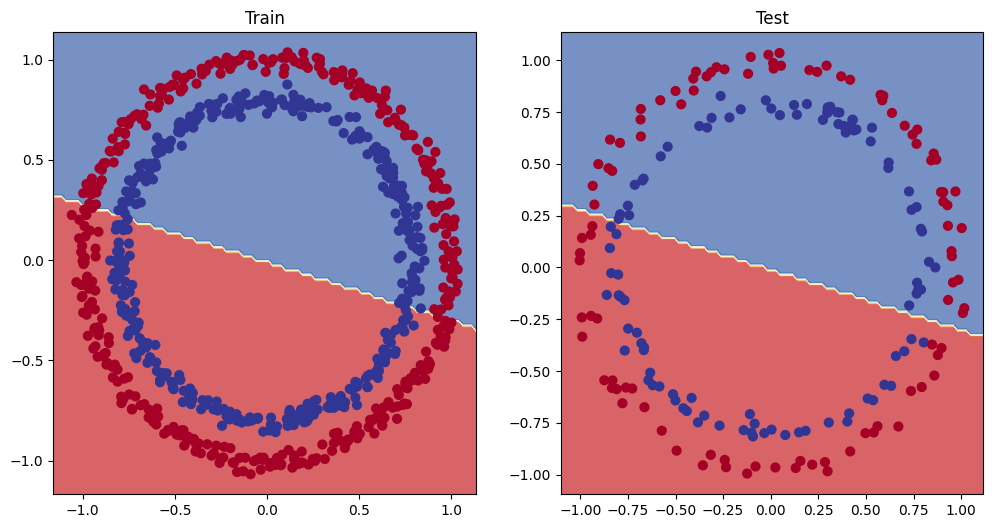

In [80]:
# Plot decision boundaries for training and test sets
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("Train")
plot_decision_boundary(model_0, X_train.to(device), Y_train.to(device))
plt.subplot(1, 2, 2)
plt.title("Test")
plot_decision_boundary(model_0, X_test.to(device), Y_test.to(device))

### 5. improving a model (from a model perspective)

* add more layers - give the model more chances to learn about patterns in the data
* add more hidden units - go from 5 hidden units to 10 hidden units
* fit for longer
* change the activation functions
* change the learining rate

These options are all from a model's prespective because they deal directly with the model, rather than the data

and because these options are all values we (as machine learning engineers and data scientists) can change, they are refferd as **Hyper Parameters** .

Let's try and improve our model by :
* adding more hidden units : 5 -> 10
* Increase the number of layers : 2 -> 3
* Increase the number of epochs : 100 -> 1000


In [81]:
print(model_0.state_dict())

OrderedDict({'0.weight': tensor([[-0.5272,  0.6587],
        [-0.5207,  0.3523],
        [ 0.2462,  0.2030],
        [-0.3814,  0.6437],
        [ 0.1593,  0.1249]]), '0.bias': tensor([-0.6169,  0.2845, -0.1185, -0.3241,  0.6224]), '1.weight': tensor([[ 0.1383, -0.1929, -0.2033,  0.0345,  0.2990]]), '1.bias': tensor([-0.0584])})


In [82]:
class CircleModuleV1(t.nn.Module):
  def __init__(self):
    super().__init__()
    self.layer1 = t.nn.Linear(in_features=2,
                              out_features=10)
    self.layer2 = t.nn.Linear(in_features=10,
                              out_features=10)
    self.layer3 = t.nn.Linear(in_features=10,
                              out_features=1)
  def forward(self, x:t.tensor):
    # option 1
    # z = self.layer1(x)
    # z = self.layer2(z)
    # z = self.layer3(z)
    # return z

    # option 2 (better way!)
    return self.layer3(self.layer2(self.layer1(x)))

model_1 = CircleModuleV1().to(device)
print(model_1.state_dict())
print('\n---------------\n')
print(list(model_0.parameters()))


OrderedDict({'layer1.weight': tensor([[ 0.5406,  0.5869],
        [-0.1657,  0.6496],
        [-0.1549,  0.1427],
        [-0.3443,  0.4153],
        [ 0.6233, -0.5188],
        [ 0.6146,  0.1323],
        [ 0.5224,  0.0958],
        [ 0.3410, -0.0998],
        [ 0.5451,  0.1045],
        [-0.3301,  0.1802]], device='cuda:0'), 'layer1.bias': tensor([-0.3258, -0.0829, -0.2872,  0.4691, -0.5582, -0.3260, -0.1997, -0.4252,
         0.0667, -0.6984], device='cuda:0'), 'layer2.weight': tensor([[ 0.2856, -0.2686,  0.2441,  0.0526, -0.1027,  0.1954,  0.0493,  0.2555,
          0.0346, -0.0997],
        [ 0.0850, -0.0858,  0.1331,  0.2823,  0.1828, -0.1382,  0.1825,  0.0566,
          0.1606, -0.1927],
        [-0.3130, -0.1222, -0.2426,  0.2595,  0.0911,  0.1310,  0.1000, -0.0055,
          0.2475, -0.2247],
        [ 0.0199, -0.2158,  0.0975, -0.1089,  0.0969, -0.0659,  0.2623, -0.1874,
         -0.1886, -0.1886],
        [ 0.2844,  0.1054,  0.3043, -0.2610, -0.3137, -0.2474, -0.2127,  0.128

In [83]:
# Create a loss function
loss_fun = t.nn.BCEWithLogitsLoss()

# Create an Optimizer
optimizer = t.optim.SGD(params=model_1.parameters(),
                        lr=0.1)

In [84]:
# Write a training & evaluation loop for model_1
t.manual_seed(42)
t.cuda.manual_seed(42)

epochs = 1000
X_train, Y_train, X_test, Y_test = X_train.to(device), Y_train.to(device), X_test.to(device), Y_test.to(device)

for epoch in range(epochs):
  model_1.train()
  Y_logits = model_1(X_train).squeeze()
  Y_logits_preds = t.round(t.sigmoid(Y_logits))


  loss = loss_fun(Y_logits, Y_train)
  loss_train = loss.item()
  acc_train = accuracy_fun(Y_train, Y_logits_preds)

  optimizer.zero_grad()

  loss.backward()
  optimizer.step()

  model_1.eval()
  with t.inference_mode():
    Y_logits_test = model_1(X_test).squeeze()
    Y_logits_preds_test = t.round(t.sigmoid(Y_logits_test))
    loss_test = loss_fun(Y_logits_test, Y_test).item()
    acc_test = accuracy_fun(Y_test, Y_logits_preds_test)
  if epoch % 100 == 0:
    print(f"epoch : {epoch:4d} | loss train : {loss_train:.4f} | accuracy of train : {acc_train:.2f} | loss test : {loss_test:.4f} | accuracy of test : {acc_test:.2f}")



epoch :    0 | loss train : 0.6940 | accuracy of train : 0.51 | loss test : 0.6926 | accuracy of test : 0.51
epoch :  100 | loss train : 0.6930 | accuracy of train : 0.50 | loss test : 0.6938 | accuracy of test : 0.48
epoch :  200 | loss train : 0.6930 | accuracy of train : 0.51 | loss test : 0.6944 | accuracy of test : 0.46
epoch :  300 | loss train : 0.6930 | accuracy of train : 0.52 | loss test : 0.6946 | accuracy of test : 0.45
epoch :  400 | loss train : 0.6930 | accuracy of train : 0.51 | loss test : 0.6946 | accuracy of test : 0.46
epoch :  500 | loss train : 0.6930 | accuracy of train : 0.51 | loss test : 0.6947 | accuracy of test : 0.46
epoch :  600 | loss train : 0.6930 | accuracy of train : 0.51 | loss test : 0.6947 | accuracy of test : 0.46
epoch :  700 | loss train : 0.6930 | accuracy of train : 0.51 | loss test : 0.6947 | accuracy of test : 0.46
epoch :  800 | loss train : 0.6930 | accuracy of train : 0.51 | loss test : 0.6947 | accuracy of test : 0.46
epoch :  900 | loss

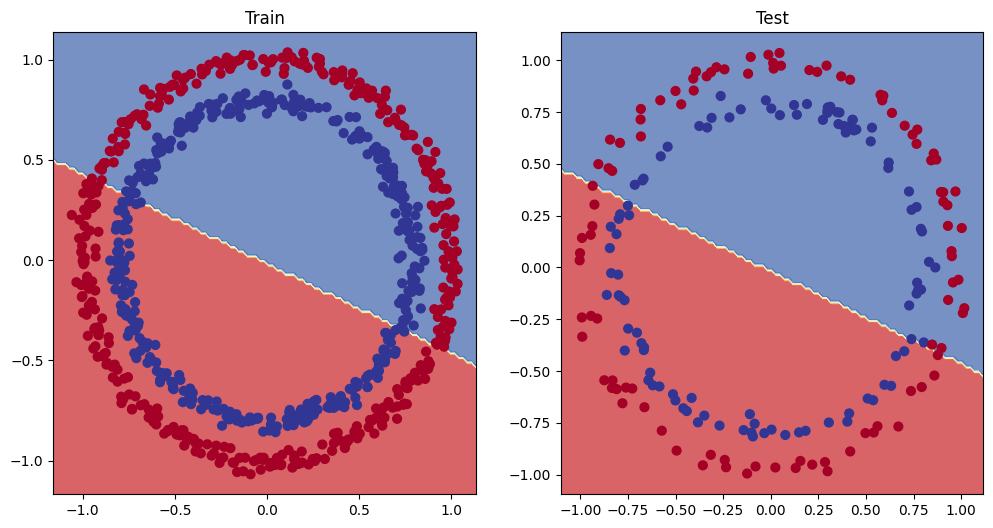

In [85]:
# Plot decision boundaries for training and test sets
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("Train")
plot_decision_boundary(model_1, X_train.to(device), Y_train.to(device))
plt.subplot(1, 2, 2)
plt.title("Test")
plot_decision_boundary(model_1, X_test.to(device), Y_test.to(device))

### 5.1 Preparing data to see if our model can fit a straight line

One way to troubleshoot to a larger problem test out a smaller problem

In [86]:
# Create some data (same as notebook 01)
weight = 0.7
bais = 0.3
start = 0
end = 1
step = 0.01

# Create data
X_regression = t.arange(start, end, step).unsqueeze(dim=1)
Y_regression = X_regression * weight + bais

print(X_regression)
print('\n--------------------------------------------------------------------------------\n')
print(Y_regression)

tensor([[0.0000],
        [0.0100],
        [0.0200],
        [0.0300],
        [0.0400],
        [0.0500],
        [0.0600],
        [0.0700],
        [0.0800],
        [0.0900],
        [0.1000],
        [0.1100],
        [0.1200],
        [0.1300],
        [0.1400],
        [0.1500],
        [0.1600],
        [0.1700],
        [0.1800],
        [0.1900],
        [0.2000],
        [0.2100],
        [0.2200],
        [0.2300],
        [0.2400],
        [0.2500],
        [0.2600],
        [0.2700],
        [0.2800],
        [0.2900],
        [0.3000],
        [0.3100],
        [0.3200],
        [0.3300],
        [0.3400],
        [0.3500],
        [0.3600],
        [0.3700],
        [0.3800],
        [0.3900],
        [0.4000],
        [0.4100],
        [0.4200],
        [0.4300],
        [0.4400],
        [0.4500],
        [0.4600],
        [0.4700],
        [0.4800],
        [0.4900],
        [0.5000],
        [0.5100],
        [0.5200],
        [0.5300],
        [0.5400],
        [0

In [87]:
print(X_regression.shape)
print('\n-------------------------------\n')
print(Y_regression.shape)

torch.Size([100, 1])

-------------------------------

torch.Size([100, 1])


In [88]:
# Create train & test split
train_split = int(0.8 * len(X_regression))
X_train_regression, Y_train_regression = X_regression[:train_split], Y_regression[:train_split]
X_test_regression, Y_test_regression = X_regression[train_split:], Y_regression[train_split:]

print(len(X_train_regression))
print(len(Y_train_regression))
print(len(X_test_regression))
print(len(Y_test_regression))
print('\n------------------------\n')
print(X_train_regression.shape)
print(Y_train_regression.shape)
print(X_test_regression.shape)
print(Y_test_regression.shape)

80
80
20
20

------------------------

torch.Size([80, 1])
torch.Size([80, 1])
torch.Size([20, 1])
torch.Size([20, 1])


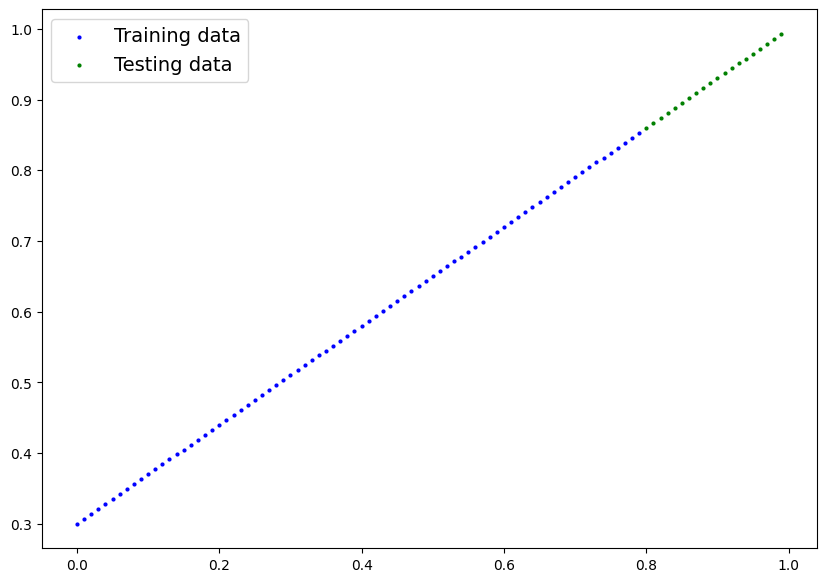

In [89]:
plot_predictions(X_train_regression,
                 Y_train_regression,
                 X_test_regression,
                 Y_test_regression)

### 5.2 Adjusting 'model_1' to fit a straight line

In [90]:
# Same architecture as model_1 (but using 'Sequential()')
model_2 = t.nn.Sequential(
    t.nn.Linear(1, 10),
    t.nn.Linear(10, 10),
    t.nn.Linear(10, 1)
).to(device)

print(model_2)

Sequential(
  (0): Linear(in_features=1, out_features=10, bias=True)
  (1): Linear(in_features=10, out_features=10, bias=True)
  (2): Linear(in_features=10, out_features=1, bias=True)
)


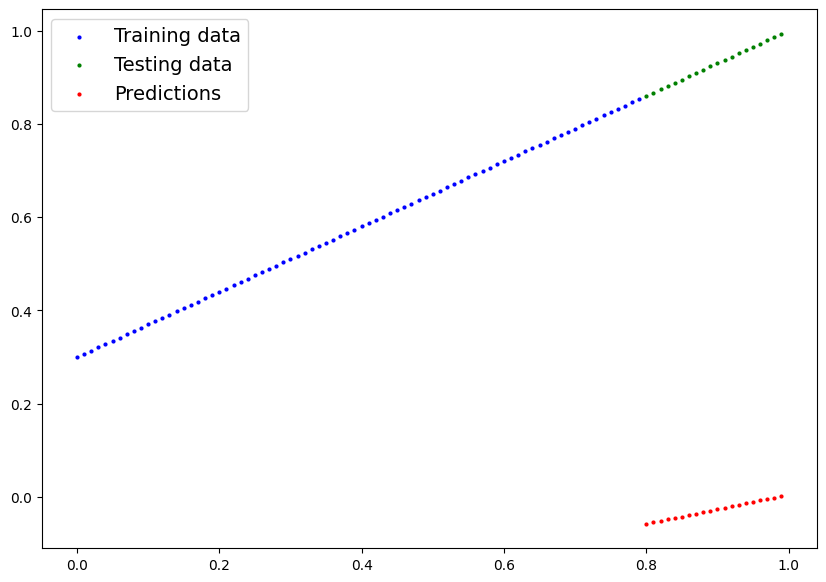

In [91]:
with t.inference_mode():
  Y_preds = model_2(X_test_regression.to(device))

plot_predictions(X_train_regression.cpu(),
                 Y_train_regression.cpu(),
                 X_test_regression.cpu(),
                 Y_test_regression.cpu(),
                 Y_preds.cpu())

In [92]:
# Loss & Optimizer
loss_fun = t.nn.L1Loss()

optimizer = t.optim.SGD(params=model_2.parameters(),
                        lr=0.01)



In [93]:
# Train the model
t.manual_seed(42)
t.cuda.manual_seed(42)

epochs = 1000

X_train_regression, Y_train_regression, X_test_regression, Y_test_regression = X_train_regression.to(device), Y_train_regression.to(device), X_test_regression.to(device), Y_test_regression.to(device)

for epoch in range(epochs):
  model_2.train()

  Y_preds = model_2(X_train_regression)
  loss = loss_fun(Y_preds, Y_train_regression)
  loss_train = loss.item()

  optimizer.zero_grad()
  loss.backward()
  optimizer.step()

  model_2.eval()
  with t.inference_mode():
    Y_preds_test = model_2(X_test_regression)
    loss_test = loss_fun(Y_preds_test, Y_test_regression).item()
  if epoch % 100 == 0:
    print(f"epoch : {epoch:4d} | loss train : {loss_train:.4f} | loss test : {loss_test:.4f}")


epoch :    0 | loss train : 0.7599 | loss test : 0.9110
epoch :  100 | loss train : 0.0286 | loss test : 0.0008
epoch :  200 | loss train : 0.0253 | loss test : 0.0021
epoch :  300 | loss train : 0.0214 | loss test : 0.0031
epoch :  400 | loss train : 0.0196 | loss test : 0.0034
epoch :  500 | loss train : 0.0194 | loss test : 0.0039
epoch :  600 | loss train : 0.0190 | loss test : 0.0038
epoch :  700 | loss train : 0.0188 | loss test : 0.0038
epoch :  800 | loss train : 0.0184 | loss test : 0.0033
epoch :  900 | loss train : 0.0180 | loss test : 0.0036


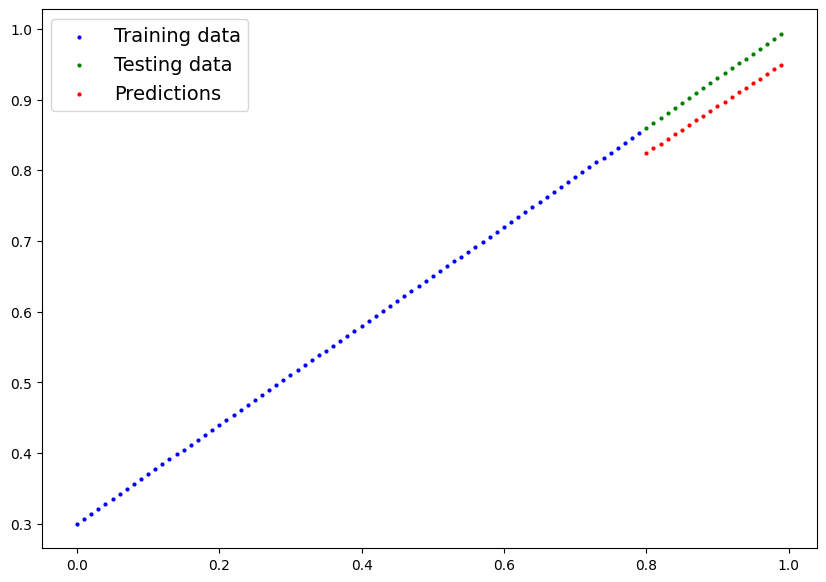

In [94]:
model_2.eval()
with t.inference_mode():
  Y_preds = model_2(X_test_regression)

plot_predictions(X_train_regression.cpu(),
                 Y_train_regression.cpu(),
                 X_test_regression.cpu(),
                 Y_test_regression.cpu(),
                 Y_preds.cpu())

### 6. the Missing piece: non-linearity

### 6.1 Recreating non-linear data (red & blue circles)


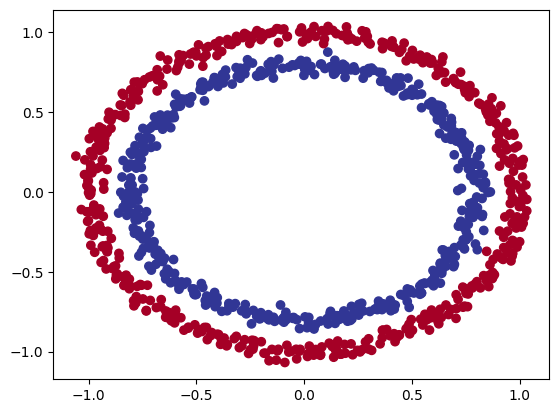

In [95]:
# Make and plot data
import matplotlib.pyplot as plt
from sklearn.datasets import make_circles

n_samples = 1000

X, y = make_circles(n_samples=n_samples,
                    noise=0.03,
                    random_state=42)

plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.RdYlBu)

In [96]:
# Convert data to tensor and than to train and test split
import torch as t
from sklearn.model_selection import train_test_split

# Turn data into Tensor
X = t.from_numpy(X).type(t.float)
y = t.from_numpy(y).type(t.float)

# split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


print(X_train)
print(y_train)
print(X_test)
print(y_test)
print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)
print(len(X_train))
print(len(y_train))
print(len(X_test))
print(len(y_test))

tensor([[ 0.6579, -0.4651],
        [ 0.6319, -0.7347],
        [-1.0086, -0.1240],
        ...,
        [ 0.0157, -1.0300],
        [ 1.0110,  0.1680],
        [ 0.5578, -0.5709]])
tensor([1., 0., 0., 0., 1., 0., 1., 1., 0., 0., 1., 0., 0., 0., 1., 0., 0., 0.,
        0., 1., 1., 1., 0., 1., 1., 1., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0.,
        1., 1., 1., 1., 1., 1., 0., 1., 0., 1., 0., 0., 0., 0., 0., 1., 0., 1.,
        1., 1., 0., 1., 1., 1., 0., 0., 0., 1., 0., 0., 1., 0., 0., 0., 1., 1.,
        1., 0., 0., 0., 0., 0., 0., 0., 1., 1., 0., 1., 0., 1., 0., 1., 0., 1.,
        1., 1., 0., 0., 0., 1., 0., 1., 1., 0., 0., 0., 0., 0., 0., 1., 0., 0.,
        0., 0., 1., 1., 0., 0., 1., 0., 1., 1., 0., 1., 0., 1., 0., 1., 0., 1.,
        0., 0., 1., 1., 1., 1., 1., 1., 1., 0., 0., 1., 1., 1., 1., 1., 0., 1.,
        1., 0., 1., 0., 0., 0., 1., 1., 0., 1., 1., 1., 1., 0., 0., 1., 1., 0.,
        0., 1., 1., 1., 1., 0., 1., 1., 0., 0., 0., 1., 1., 1., 1., 1., 1., 1.,
        0., 1., 1.

### 6.2 Building a model with non-linearity

* Linear = straight linear
* non-Linear = non-straight lines


In [97]:
# Build a model with non-linear activation functions
from torch import nn

class CircleModelV2(nn.Module):
  def __init__(self):
    super().__init__()
    self.layer1 = nn.Linear(2, 10)
    self.layer2 = nn.Linear(10, 10)
    self.layer3 = nn.Linear(10, 1)
    self.relu = nn.ReLU() # ReLU is a non-Linear activation functions

  def forward(self, x:t.tensor):
    # where should we put our non-Linear activation functions ?
    return self.layer3(self.relu(self.layer2(self.relu(self.layer1(x)))))

model_3 = CircleModelV2()
model_3 = model_3.to(device)
print(model_3)

CircleModelV2(
  (layer1): Linear(in_features=2, out_features=10, bias=True)
  (layer2): Linear(in_features=10, out_features=10, bias=True)
  (layer3): Linear(in_features=10, out_features=1, bias=True)
  (relu): ReLU()
)


In [98]:
# Create a loss function
loss_fun = t.nn.BCEWithLogitsLoss()

# Create an Optimizer
optimizer = t.optim.SGD(params=model_3.parameters(),
                        lr=0.1)

In [99]:
# Write a training & evaluation loop for model_1
t.manual_seed(42)
t.cuda.manual_seed(42)

epochs = 5000
X_train, y_train = X_train.to(device), y_train.to(device)
X_test, y_test = X_test.to(device), y_test.to(device)

# print(f"Model device  : {next(model_3.parameters()).device}")
# print(f"X_train device: {X_train.device}")

for epoch in range(epochs):
  model_3.train()
  y_logits = model_3(X_train).squeeze()
  y_logits_preds = t.round(t.sigmoid(y_logits))


  loss = loss_fun(y_logits, y_train)
  loss_train = loss.item()
  acc_train = accuracy_fun(y_train, y_logits_preds)

  optimizer.zero_grad()

  loss.backward()
  optimizer.step()

  model_3.eval()
  with t.inference_mode():
    y_logits_test = model_3(X_test).squeeze()
    y_logits_preds_test = t.round(t.sigmoid(y_logits_test))
    loss_test = loss_fun(y_logits_test, y_test).item()
    acc_test = accuracy_fun(y_test, y_logits_preds_test)
  if epoch % 100 == 0:
    print(f"epoch : {epoch:4d} | loss train : {loss_train:.4f} | accuracy of train : {acc_train:.2f} | loss test : {loss_test:.4f} | accuracy of test : {acc_test:.2f}")



epoch :    0 | loss train : 0.6929 | accuracy of train : 0.50 | loss test : 0.6932 | accuracy of test : 0.50
epoch :  100 | loss train : 0.6912 | accuracy of train : 0.53 | loss test : 0.6910 | accuracy of test : 0.52
epoch :  200 | loss train : 0.6898 | accuracy of train : 0.53 | loss test : 0.6894 | accuracy of test : 0.55
epoch :  300 | loss train : 0.6879 | accuracy of train : 0.53 | loss test : 0.6872 | accuracy of test : 0.56
epoch :  400 | loss train : 0.6852 | accuracy of train : 0.53 | loss test : 0.6841 | accuracy of test : 0.56
epoch :  500 | loss train : 0.6810 | accuracy of train : 0.53 | loss test : 0.6794 | accuracy of test : 0.56
epoch :  600 | loss train : 0.6751 | accuracy of train : 0.55 | loss test : 0.6729 | accuracy of test : 0.56
epoch :  700 | loss train : 0.6666 | accuracy of train : 0.58 | loss test : 0.6632 | accuracy of test : 0.59
epoch :  800 | loss train : 0.6516 | accuracy of train : 0.64 | loss test : 0.6476 | accuracy of test : 0.68
epoch :  900 | loss

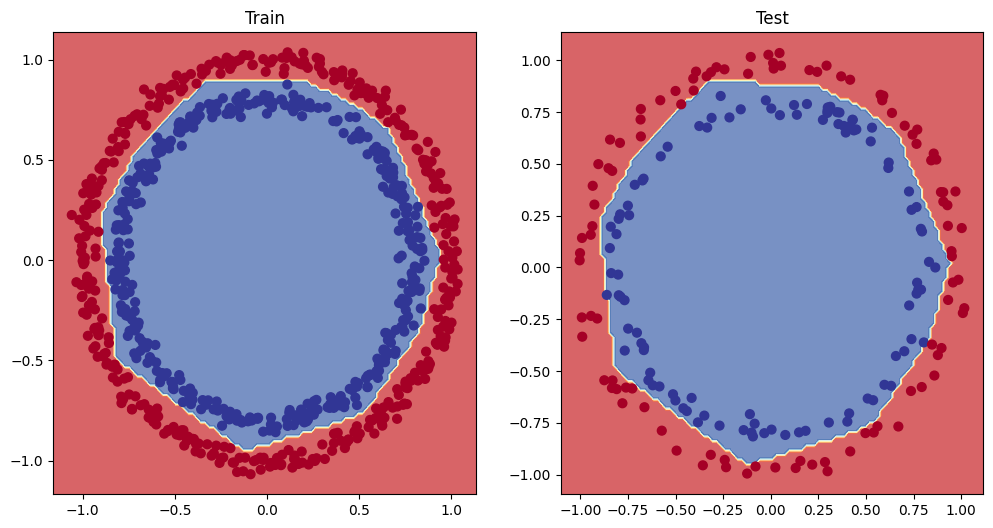

In [100]:
# Plot decision boundaries for training and test sets
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("Train")
plot_decision_boundary(model_3, X_train.to(device), y_train.to(device))
plt.subplot(1, 2, 2)
plt.title("Test")
plot_decision_boundary(model_3, X_test.to(device), y_test.to(device))

In [101]:
model_3.eval()
with t.inference_mode():
  y_preds = t.round(t.sigmoid(model_3(X_test.cpu()))).squeeze()

# مقایسه
correct = (y_preds == y_test.cpu()).sum().item()
total = len(y_test)
wrong = total - correct

print(f"✅ Correct: {correct}/{total}")
print(f"❌ Wrong  : {wrong}/{total}")
print(f"📊 Accuracy: {correct/total*100:.2f}%")

✅ Correct: 199/200
❌ Wrong  : 1/200
📊 Accuracy: 99.50%


### 7. Putting it all together with a multi-class classification problem

* Binary classification = one thing or another (cat vs. dog, spam vs. not spam)
* Multi-class classification = more than one thing or another (cat vs. dog vs. chicken)

### 7.1 Creating a toy multi-class dataset


In [102]:
import torch as t
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.model_selection import train_test_split

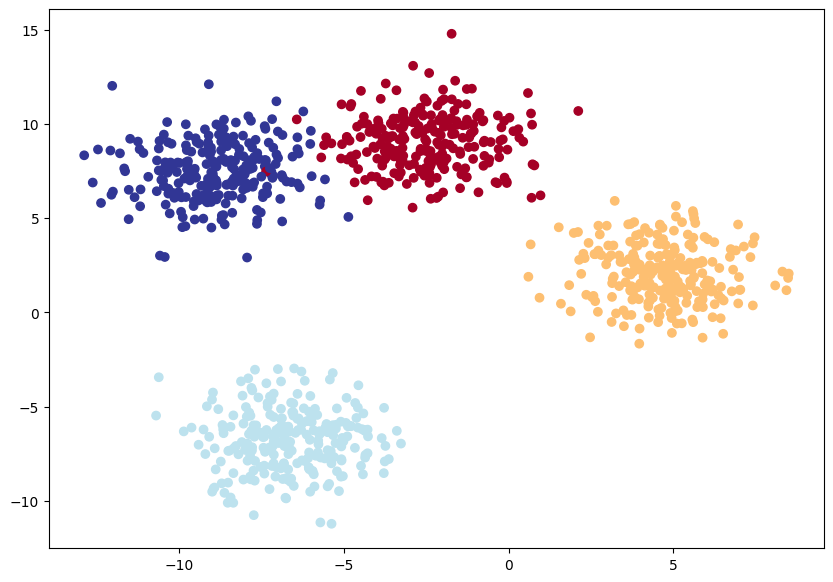

In [103]:
# Set the hyperParameters for data Creation
NUM_CLASSES = 4
NUM_FEATURES = 2
RANDOM_SEED = 42

# 1. create multi-class data
X_blob, y_blob = make_blobs(n_samples=1000,
                            n_features=NUM_FEATURES,
                            centers=NUM_CLASSES,
                            cluster_std=1.5,
                            random_state=RANDOM_SEED)

# 2. Turn data into tensors
X_blob = t.from_numpy(X_blob).type(t.float)
y_blob = t.from_numpy(y_blob).type(t.float)

# 3. Split into train and test
X_blob_train, X_blob_test, y_blob_train, y_blob_test = train_test_split(X_blob, y_blob, test_size=0.2, random_state=RANDOM_SEED)

# 4. Plot data
plt.figure(figsize=(10, 7))
plt.scatter(X_blob[:, 0], X_blob[:, 1], c=y_blob, cmap=plt.cm.RdYlBu)


### 7.2 Building a multi-class classification model in pytorch

In [104]:
# Create device agnostic code
device = 'cuda' if t.cuda.is_available() else 'cpu'
print(device)

cuda


In [105]:
# Build multi-class classification model
class blobModule(nn.Module):
  def __init__(self, input_features, output_features, hidden_units=8):
    super().__init__()
    self.layer_stack = nn.Sequential(
        t.nn.Linear(in_features=input_features,
                  out_features=hidden_units),
        t.nn.Linear(in_features=hidden_units,
                  out_features=hidden_units),
        t.nn.Linear(in_features=hidden_units,
                  out_features=output_features)
    )
  def forward(self, x:t.tensor):
    return self.layer_stack(x)


In [106]:
print(X_blob_train)
print(y_blob_train)
print(X_blob_test)
print(y_blob_test)

print(X_blob_train.shape)
print(y_blob_train.shape)
print(X_blob_test.shape)
print(y_blob_test.shape)

print(len(X_blob_train))
print(len(y_blob_train))
print(len(X_blob_test))
print(len(y_blob_test))


tensor([[ 5.0405,  3.3076],
        [-2.6249,  9.5260],
        [-8.5240, -9.0402],
        ...,
        [-1.7366,  9.7850],
        [-6.8139, -7.1006],
        [-9.0311,  4.5007]])
tensor([1., 0., 2., 2., 0., 0., 0., 1., 3., 0., 0., 0., 3., 2., 3., 2., 1., 1.,
        3., 2., 2., 2., 3., 1., 3., 2., 3., 0., 1., 0., 0., 1., 1., 3., 0., 2.,
        2., 1., 1., 3., 1., 1., 2., 3., 3., 0., 0., 0., 1., 0., 0., 0., 2., 0.,
        1., 1., 0., 0., 2., 2., 3., 1., 0., 2., 1., 3., 2., 2., 2., 1., 0., 2.,
        3., 1., 1., 1., 2., 0., 0., 1., 2., 3., 1., 3., 3., 2., 3., 3., 2., 2.,
        1., 0., 0., 1., 2., 1., 3., 1., 2., 1., 3., 3., 3., 0., 2., 1., 2., 3.,
        1., 1., 2., 0., 3., 3., 2., 0., 2., 0., 3., 2., 0., 0., 2., 2., 0., 1.,
        2., 0., 3., 3., 2., 3., 2., 1., 3., 1., 1., 1., 1., 0., 0., 1., 0., 2.,
        3., 0., 0., 0., 0., 0., 1., 0., 3., 0., 0., 2., 2., 0., 0., 3., 0., 3.,
        3., 3., 0., 2., 0., 1., 2., 2., 2., 3., 0., 1., 1., 0., 1., 2., 0., 3.,
        2., 1., 3.

In [107]:
model_4 = blobModule(input_features=2,
                     output_features=4,
                     hidden_units=8).to(device)

In [108]:
model_4

blobModule(
  (layer_stack): Sequential(
    (0): Linear(in_features=2, out_features=8, bias=True)
    (1): Linear(in_features=8, out_features=8, bias=True)
    (2): Linear(in_features=8, out_features=4, bias=True)
  )
)

### 7.3 Create a Loss Function and an Optimizer for multi-class classification Model

In [109]:
# Create a loss function fot multi-class classification
loss_fun = t.nn.CrossEntropyLoss()

# Create a optimizer fot multi-class classification
optimizer = t.optim.SGD(params=model_4.parameters(),
                        lr=0.1)

### 7.4 Getting prediction probabilities for multi-class classification

In [110]:
model_4.eval()
with t.inference_mode():
  y_test_logits = model_4(X_blob_test.to(device))
print(y_test_logits[:5])
y_preds = t.softmax(y_test_logits, dim=1)
print(y_preds[:5])

tensor([[-1.2549, -0.8112, -1.4795, -0.5696],
        [ 1.7168, -1.2270,  1.7367,  2.1010],
        [ 2.2400,  0.7714,  2.6020,  1.0107],
        [-0.7993, -0.3723, -0.9138, -0.5388],
        [-0.4332, -1.6117, -0.6891,  0.6852]], device='cuda:0')
tensor([[0.1872, 0.2918, 0.1495, 0.3715],
        [0.2824, 0.0149, 0.2881, 0.4147],
        [0.3380, 0.0778, 0.4854, 0.0989],
        [0.2118, 0.3246, 0.1889, 0.2748],
        [0.1945, 0.0598, 0.1506, 0.5951]], device='cuda:0')


In [111]:
print(f"y_blob_train shape : {y_blob_train.shape}")
print(f"y_blob_preds shape : {y_preds.shape}")
print(f"y_blob_logits shape: {y_logits.shape}")

y_blob_train shape : torch.Size([800])
y_blob_preds shape : torch.Size([200, 4])
y_blob_logits shape: torch.Size([800])


In [112]:
def accuracy_fun(y_true, y_logits):
    y_preds = t.argmax(y_logits, dim=1)   # [800, 4] → [800]
    correct = (y_true == y_preds).float().mean().item()
    return correct * 100

### 7.3 train & test loop

In [113]:
y_blob_train = y_blob_train.type(t.LongTensor)
y_blob_test = y_blob_test.type(t.LongTensor)
X_blob_train, y_blob_train = X_blob_train.to(device), y_blob_train.to(device)
X_blob_test, y_blob_test = X_blob_test.to(device), y_blob_test.to(device)

epochs = 1000

for epoch in range(epochs):
  model_4.train()

  y_blob_logits = model_4(X_blob_train).squeeze()
  y_blob_preds = t.softmax(y_blob_logits, dim=1)

  loss = loss_fun(y_blob_logits, y_blob_train)
  loss_train = loss.item()
  acc_train = accuracy_fun(y_blob_train, y_blob_preds)

  optimizer.zero_grad()
  loss.backward()

  optimizer.step()

  model_4.eval()
  with t.inference_mode():
    y_blob_logits_test = model_4(X_blob_test).squeeze()
    loss_test = loss_fun(y_blob_logits_test, y_blob_test).item()
    y_preds_test = t.softmax(y_blob_logits_test, dim=1)
    acc_test = accuracy_fun(y_blob_test, y_preds_test)

  if epoch % 100 == 0:
    print(f"epoch : {epoch:4d} | loss train : {loss_train:.4f} | accuracy of train : {acc_train:.2f} | loss test : {loss_test:.4f} | accuracy of test : {acc_test:.2f}")



epoch :    0 | loss train : 1.0432 | accuracy of train : 65.50 | loss test : 0.5786 | accuracy of test : 95.50
epoch :  100 | loss train : 0.0318 | accuracy of train : 99.12 | loss test : 0.0229 | accuracy of test : 99.50
epoch :  200 | loss train : 0.0271 | accuracy of train : 99.12 | loss test : 0.0170 | accuracy of test : 99.50
epoch :  300 | loss train : 0.0256 | accuracy of train : 99.25 | loss test : 0.0150 | accuracy of test : 99.50
epoch :  400 | loss train : 0.0249 | accuracy of train : 99.25 | loss test : 0.0139 | accuracy of test : 99.50
epoch :  500 | loss train : 0.0244 | accuracy of train : 99.25 | loss test : 0.0132 | accuracy of test : 99.50
epoch :  600 | loss train : 0.0241 | accuracy of train : 99.25 | loss test : 0.0127 | accuracy of test : 99.50
epoch :  700 | loss train : 0.0238 | accuracy of train : 99.25 | loss test : 0.0122 | accuracy of test : 99.50
epoch :  800 | loss train : 0.0235 | accuracy of train : 99.25 | loss test : 0.0119 | accuracy of test : 99.50
e

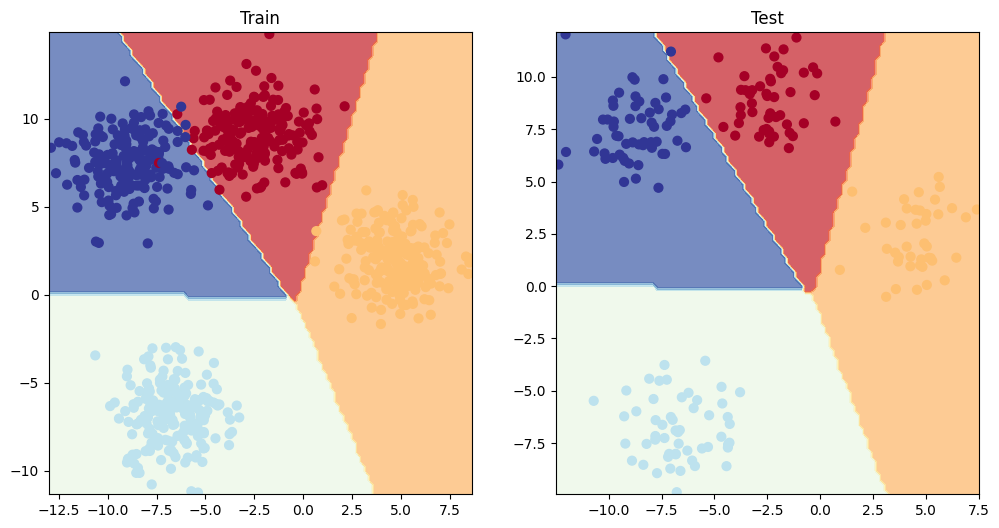

In [114]:
# Plot decision boundaries for training and test sets
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("Train")
plot_decision_boundary(model_4, X_blob_train.to(device), y_blob_train.to(device))
plt.subplot(1, 2, 2)
plt.title("Test")
plot_decision_boundary(model_4, X_blob_test.to(device), y_blob_test.to(device))

### 7.4 making & evaluating prediction

In [120]:
model_4.eval()
with t.inference_mode():
  y_blob_logits_test = model_4(X_blob_test.cpu())
  y_blob_preds_test = t.softmax(y_blob_logits_test, dim=1) # convert logits -> prediction probabilities

print('y Logit : ',y_blob_logits_test[:5])
print('y preds : ',y_blob_preds_test[:5])

y Logit :  tensor([[  6.1117,  18.9106, -22.9632, -14.6995],
        [  9.5662, -23.8503,   5.8412,  17.7025],
        [ -8.4025, -21.8530,  30.5466,  17.0857],
        [  2.1340,  14.6655, -13.7829, -11.2652],
        [ 13.2141,   3.9343, -21.4953,  -3.6479]])
y preds :  tensor([[2.7638e-06, 1.0000e+00, 6.5229e-19, 2.5312e-15],
        [2.9263e-04, 8.9892e-19, 7.0561e-06, 9.9970e-01],
        [1.2151e-17, 1.7504e-23, 1.0000e+00, 1.4255e-06],
        [3.6113e-06, 1.0000e+00, 4.4163e-13, 5.4759e-12],
        [9.9991e-01, 9.3284e-05, 8.4312e-16, 4.7522e-08]])


In [121]:
# convert prediction probabilities -> prediction Labels
y_blob_preds = t.argmax(y_blob_preds_test, dim=1)

print(y_blob_preds[:10])


tensor([1, 3, 2, 1, 0, 3, 2, 0, 2, 0])
